# CIFAR3 Image Viewer

This notebook loads CIFAR-10, filters to CIFAR3 classes (`dog`, `cat`, `bird`), and shows sample images with labels.

In [1]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets

# Map CIFAR-10 labels -> CIFAR3 labels used in this repo
KEEP_LABELS = [5, 3, 2]  # dog, cat, bird in CIFAR-10
CIFAR3_CLASSES = ['dog', 'cat', 'bird']
LABEL_MAP = {old: new for new, old in enumerate(KEEP_LABELS)}

# Resolve dataset root robustly whether cwd is workspace root or notebooks/
cwd = Path.cwd()
project_root = cwd if (cwd / 'data').exists() else cwd.parent
dataset_root = project_root / '_CIFAR'
print('Using dataset root:', dataset_root.resolve())

Using dataset root: ./_CIFAR


In [2]:
train_ds = datasets.CIFAR10(root=str(dataset_root), train=True, download=True)

targets = np.array(train_ds.targets, dtype=np.int64)
keep_mask = np.isin(targets, KEEP_LABELS)
keep_indices = np.where(keep_mask)[0]

print(f'Total train images: {len(train_ds)}')
print(f'CIFAR3 train images: {len(keep_indices)}')

Total train images: 50000
CIFAR3 train images: 15000


In [3]:
def show_random_cifar3_images(n=24, seed=16, figsize=(12, 10)):
    random.seed(seed)
    n = min(n, len(keep_indices))
    chosen = random.sample(keep_indices.tolist(), n)

    cols = 6
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, chosen):
        img, y = train_ds[idx]
        mapped = LABEL_MAP[int(y)]
        ax.imshow(img)
        ax.set_title(CIFAR3_CLASSES[mapped], fontsize=10)
        ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

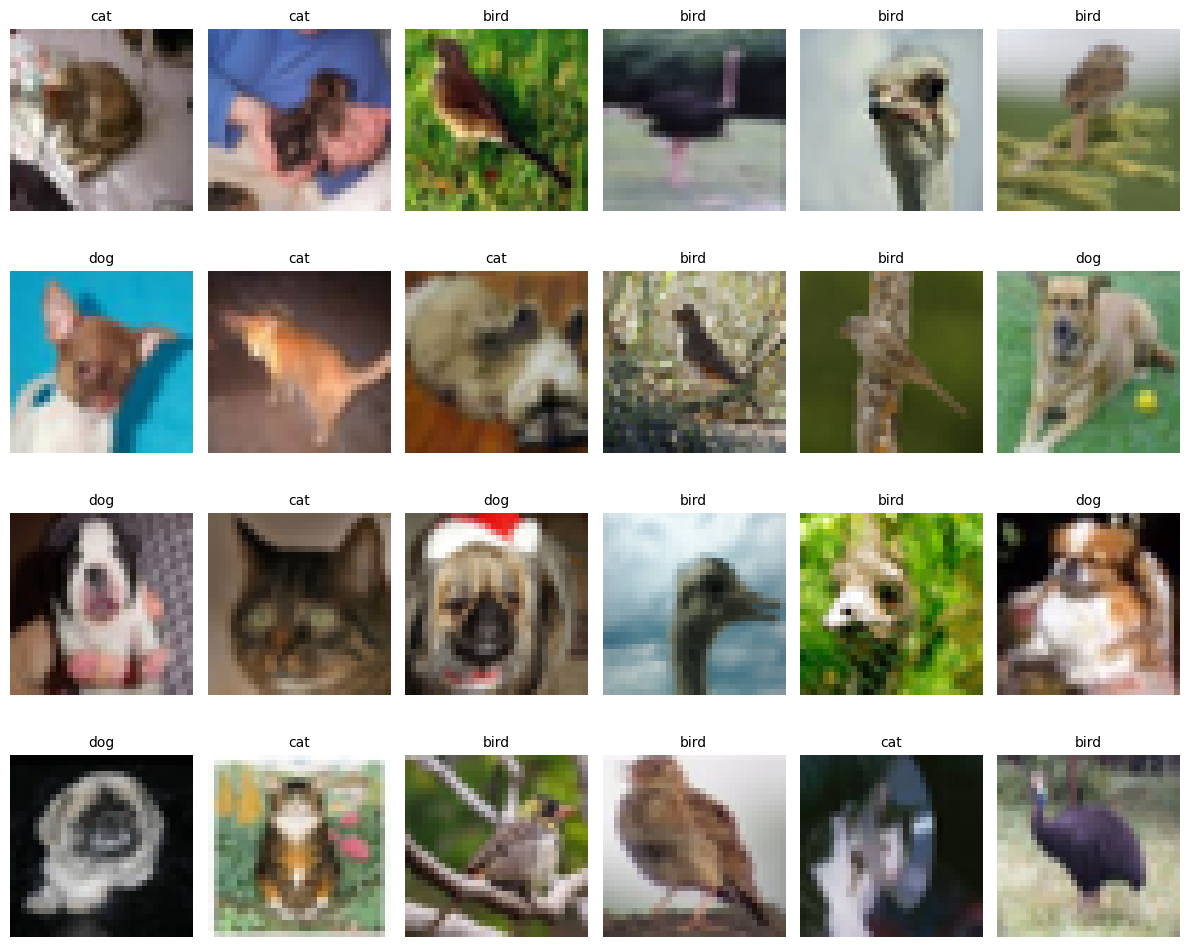

In [4]:
show_random_cifar3_images(n=24, seed=16)